# CW2 reference solution — predicting `HighHealthNeeds`

**Instructor-facing.** A worked pass through the improvement ladder CW2 asks students to
discover, serving three purposes: evidence that the dataset is fit for purpose, a marking
reference, and the "here is what I got, try to beat this" benchmark.

**How this notebook is organised.** Five models are introduced at the very start and then
carried through *every* stage. Each stage applies one change to **all five**, scores them on
**the same set of metrics**, and prints a results table. That way any row can be compared
against the same row at any other stage, and no improvement is visible for one model but
invisible for another.

The metrics, at every stage, are: accuracy, balanced accuracy, precision, recall, F1, and cost
per person for each of the two stakeholders. Everything comes from `model.predict()` — there
are no predicted probabilities and no decision thresholds anywhere.

**A finding worth stating up front**, because it runs through the whole notebook: as the
pipeline improves, **accuracy goes down**. Recall, F1, balanced accuracy and cost all improve
together, and plain accuracy moves the other way. That is not a bug, and §12 comes back to it.

## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             precision_score, recall_score)
from imblearn.over_sampling import SMOTE

from costs import (COST_EMPLOYER, COST_PUBLIC_HEALTH, cost_per_person,
                   do_nothing_cost, confusion_counts)

pd.set_option('display.width', 220)
RANDOM_STATE = 42
TARGET = 'HighHealthNeeds'

SERIES = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']
INK, SECONDARY, MUTED = '#0b0b0b', '#52514e', '#898781'
plt.rcParams.update({
    'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb',
    'axes.edgecolor': '#c3c2b7', 'axes.labelcolor': SECONDARY, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': '#e1e0d9', 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10, 'figure.dpi': 110, 'legend.frameon': False,
})

### Data preparation helpers

`naive_clean` is what the starter notebook does. `careful_clean` is what a student should
arrive at. Both are defined here so the two can be swapped at a single point.

In [2]:
ORDINAL_SCALES = {
    'Smoking Status': ['Never', 'Former', 'Vaper', 'Light Smoker', 'Heavy Smoker'],
    'Alcohol Level': ['Non-Drinker', 'Light', 'Moderate', 'Heavy'],
    'Stress Level': ['Low', 'Medium', 'High'],
    'Physical Activity Level': ['Sedentary', 'Lightly Active', 'Moderately Active', 'Very Active'],
    'Sleep Quality': ['Poor', 'Fair', 'Good', 'Excellent'],
    'Health Issues': ['No Issues', 'Mild', 'Moderate', 'Severe'],
    'SelfRatedHealth': ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent'],
}

def encode(df, keep_self_rated_health=False):
    d = df.copy()
    for column, order in ORDINAL_SCALES.items():
        if column == 'SelfRatedHealth' and not keep_self_rated_health:
            continue
        d[column] = d[column].map({value: i for i, value in enumerate(order)})
    if not keep_self_rated_health:
        d = d.drop(columns=['SelfRatedHealth'])
    d = pd.get_dummies(d, columns=['Country', 'Gender'], drop_first=True)
    y = d.pop(TARGET)
    return d.drop(columns=['ID']).astype(float), y

def naive_clean(df):
    """The starter notebook's approach: drop duplicates, drop any incomplete row."""
    return df.drop_duplicates().dropna()

def careful_clean(df):
    """Repair the anomalies instead of discarding the rows; impute instead of dropping."""
    d = df.drop_duplicates().copy()
    age_typo = d['Age'] > 100
    d.loc[age_typo, 'Age'] = d.loc[age_typo, 'Age'].map(lambda v: int(str(int(v))[:-1]))
    bmi_typo = d['BMI'] > 60
    d.loc[bmi_typo, 'BMI'] = (d.loc[bmi_typo, 'BMI'] / 10).round(1)
    for column in d.columns:
        if d[column].isna().any():
            fill = d[column].median() if d[column].dtype != object else d[column].mode()[0]
            d[column] = d[column].fillna(fill)
    return d

dev_raw = pd.read_csv('coffee_health_v3_dev.csv')
test_raw = pd.read_csv('coffee_health_v3_test.csv')
print(f'development {len(dev_raw)} rows    held-out test {len(test_raw)} rows')

development 10040 rows    held-out test 3060 rows


### The five models

Introduced now, and carried unchanged through every stage that follows. They span the obvious
families a student would reach for: one linear, one instance-based, one single tree, and two
ensembles.

`build_models()` returns fresh, unfitted instances each time it is called, so no stage can
accidentally inherit a model fitted at an earlier one.

In [3]:
def build_models(class_weight=None, tuned=None):
    """Fresh instances of all five models.

    class_weight='balanced' is passed to every model that supports it. K-NN does not --
    there is no such parameter for a nearest-neighbour vote -- which is exactly why SMOTE
    matters for it in Stage 5.
    """
    tuned = tuned or {}
    return {
        'Logistic Regression': LogisticRegression(
            max_iter=3000, class_weight=class_weight, **tuned.get('Logistic Regression', {})),
        'K-Nearest Neighbours': KNeighborsClassifier(
            **tuned.get('K-Nearest Neighbours', {})),
        'Decision Tree': DecisionTreeClassifier(
            class_weight=class_weight, random_state=RANDOM_STATE,
            **tuned.get('Decision Tree', {})),
        'Random Forest': RandomForestClassifier(
            n_estimators=300, class_weight=class_weight, random_state=RANDOM_STATE,
            n_jobs=-1, **tuned.get('Random Forest', {})),
        'Gradient Boosting': HistGradientBoostingClassifier(
            class_weight=class_weight, random_state=RANDOM_STATE,
            **tuned.get('Gradient Boosting', {})),
    }

MODEL_ORDER = list(build_models())
print('\n'.join(MODEL_ORDER))

Logistic Regression
K-Nearest Neighbours
Decision Tree
Random Forest
Gradient Boosting


### Scoring, applied identically everywhere

`evaluate` fits every model on the same training data, scores every model on the same
validation data, and records the same seven metrics for each. Every result in this notebook
goes through it, and every result is kept in `RESULTS` so §12 can reconstruct the whole
journey.

In [4]:
METRICS = ['accuracy', 'balanced_acc', 'precision', 'recall', 'f1',
           'agency EUR', 'employer EUR']

RESULTS = []      # one row per (stage, model), for the summary in Stage 12

def score(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_acc': balanced_accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'agency EUR': cost_per_person(y_true, y_pred, COST_PUBLIC_HEALTH),
        'employer EUR': cost_per_person(y_true, y_pred, COST_EMPLOYER),
    }

# K-Nearest Neighbours has no class_weight parameter, so from Stage 5 onwards it is
# trained on SMOTE-resampled data instead. Every model therefore gets the best imbalance
# handling available to it, which is the consistent treatment -- not the identical one.
SMOTE_MODELS = ('K-Nearest Neighbours',)

def evaluate(models, X_fit, y_fit, X_eval, y_eval, stage, record=True, smote_for=()):
    """Fit and score every model. Returns (results_frame, fitted_models).

    Models named in `smote_for` are fitted on a SMOTE-resampled copy of the training
    data; everything else is fitted on it as given. Resampling never touches X_eval.
    """
    rows, fitted = [], {}
    resampled = None
    if smote_for:
        resampled = SMOTE(random_state=RANDOM_STATE).fit_resample(X_fit, y_fit)
    for name, model in models.items():
        if name in smote_for:
            model.fit(*resampled)
        else:
            model.fit(X_fit, y_fit)
        fitted[name] = model
        rows.append({'model': name, **score(y_eval, model.predict(X_eval))})
    frame = pd.DataFrame(rows).set_index('model').reindex(MODEL_ORDER)
    if record:
        for name, row in frame.iterrows():
            RESULTS.append({'stage': stage, 'model': name, **row.to_dict()})
    return frame, fitted

def show(frame, title=None):
    if title:
        print(title)
    print(frame.round(3).to_string())

def delta(stage_now, stage_before, metrics=('accuracy', 'recall', 'f1', 'agency EUR')):
    """Change in each metric, per model, between two recorded stages."""
    history = pd.DataFrame(RESULTS)
    now = history[history['stage'] == stage_now].set_index('model')
    before = history[history['stage'] == stage_before].set_index('model')
    shared = [m for m in MODEL_ORDER if m in now.index and m in before.index]
    return (now.loc[shared, list(metrics)] - before.loc[shared, list(metrics)]).round(3)

---
## Stage 1 — the starter pipeline, as handed out

Two models, naive cleaning, no scaling, defaults, a single hold-out split. `SelfRatedHealth`
is still in the feature set, exactly as the starter notebook leaves it.

In [5]:
dev_naive = naive_clean(dev_raw)
X_naive, y_naive = encode(dev_naive, keep_self_rated_health=True)
Xn_train, Xn_val, yn_train, yn_val = train_test_split(
    X_naive, y_naive, test_size=0.2, random_state=RANDOM_STATE)

print(f'rows after naive cleaning: {len(dev_naive)} of {len(dev_raw)} '
      f'({len(dev_naive)/len(dev_raw):.0%})')
print(f'predict-everyone-negative accuracy: {1 - yn_val.mean():.3f}')
print()

starter = {k: v for k, v in build_models().items()
           if k in ('Logistic Regression', 'K-Nearest Neighbours')}
starter_results, _ = evaluate(starter, Xn_train, yn_train, Xn_val, yn_val,
                              stage='1 starter')
show(starter_results)

rows after naive cleaning: 7385 of 10040 (74%)
predict-everyone-negative accuracy: 0.802



                      accuracy  balanced_acc  precision  recall     f1  agency EUR  employer EUR
model                                                                                           
Logistic Regression      0.855         0.681      0.762   0.392  0.518     264.218       325.999
K-Nearest Neighbours     0.766         0.499      0.195   0.058  0.089     316.107       372.187
Decision Tree              NaN           NaN        NaN     NaN    NaN         NaN           NaN
Random Forest              NaN           NaN        NaN     NaN    NaN         NaN           NaN
Gradient Boosting          NaN           NaN        NaN     NaN    NaN         NaN           NaN


**The finding.** Both models land at or below the accuracy of a single line of code that
predicts "no" for everybody, and both find almost none of the people who needed help. Look at
the recall column rather than the accuracy column: that is the number both stakeholders are
paying for.

---
## Stage 2 — throw more models at it

The natural first instinct: the two models are not working, so try some more. Same data, same
lack of scaling, same defaults — only the model list changes.

In [6]:
stage2, _ = evaluate(build_models(), Xn_train, yn_train, Xn_val, yn_val,
                     stage='2 more models')
show(stage2)

                      accuracy  balanced_acc  precision  recall     f1  agency EUR  employer EUR
model                                                                                           
Logistic Regression      0.855         0.681      0.762   0.392  0.518     264.218       325.999
K-Nearest Neighbours     0.766         0.499      0.195   0.058  0.089     316.107       372.187
Decision Tree            0.816         0.704      0.537   0.519  0.528     255.579       341.415
Random Forest            0.873         0.735      0.779   0.505  0.613     248.517       315.762
Gradient Boosting        0.873         0.757      0.737   0.563  0.638     241.842       314.726


**The finding, and it is the important one for this stage.** Adding three more models — including
two ensembles that are far more expressive than logistic regression — buys very little. Recall
stays poor across the board. The problem was never the model family.

This is worth doing explicitly rather than skipping to the answer, because "try a more powerful
model" is the most common first move and the least productive one here. Everything that follows
changes the *pipeline* rather than the model list, and every one of those changes is worth more
than this was.

---
## Stage 3 — data quality

Repair the anomalies rather than discarding the rows, impute rather than dropping, and stop
throwing away a quarter of the data. `SelfRatedHealth` is also dropped from here on — Stage 9
explains why.

In [7]:
dev_clean = careful_clean(dev_raw)
X, y = encode(dev_clean)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f'age anomalies repaired: {(dev_raw["Age"] > 100).sum()}')
print(f'BMI anomalies repaired: {(dev_raw["BMI"] > 60).sum()}')
print(f'rows retained: naive {len(dev_naive)}  vs  careful {len(dev_clean)} '
      f'(+{len(dev_clean)/len(dev_naive) - 1:.0%})')

dropped = dev_raw[dev_raw.isna().any(axis=1)]
kept = dev_raw.dropna()
print(f'and the dropped rows were not a random sample: mean age '
      f'{dropped["Age"].where(dropped["Age"] <= 100).mean():.1f} dropped '
      f'vs {kept["Age"].where(kept["Age"] <= 100).mean():.1f} kept')
print()

stage3, _ = evaluate(build_models(), X_train, y_train, X_val, y_val,
                     stage='3 data quality')
show(stage3)
print()
show(delta('3 data quality', '2 more models'), 'change against Stage 2:')

age anomalies repaired: 71
BMI anomalies repaired: 56
rows retained: naive 7385  vs  careful 10000 (+35%)
and the dropped rows were not a random sample: mean age 42.9 dropped vs 39.9 kept



                      accuracy  balanced_acc  precision  recall     f1  agency EUR  employer EUR
model                                                                                           
Logistic Regression      0.802         0.500      0.000   0.000  0.000     316.800       356.400
K-Nearest Neighbours     0.776         0.509      0.252   0.068  0.107     312.945       367.110
Decision Tree            0.780         0.650      0.444   0.434  0.439     270.145       358.335
Random Forest            0.850         0.682      0.717   0.404  0.517     263.125       327.375
Gradient Boosting        0.850         0.712      0.664   0.485  0.561     253.995       326.385

change against Stage 2:
                      accuracy  recall     f1  agency EUR
model                                                    
Logistic Regression     -0.053  -0.392 -0.518      52.582
K-Nearest Neighbours     0.010   0.010  0.018      -3.162
Decision Tree           -0.035  -0.084 -0.088      14.566
Random

**The finding.** The metrics barely move, and for some models they move slightly the wrong way.
That is an honest result and worth reporting as one.

Two reasons to make the change anyway. First, the rows being discarded were **not random** —
missingness rises with age, so `dropna()` systematically removed older respondents, who are the
highest-risk group. A model trained on the survivors is fitted to a younger population than the
one it will be used on. Second, the extra 35% of data pays off later, once the pipeline can
actually make use of it.

Students should expect some changes to pay nothing on their own. Reporting a change that did not
move the metrics, and arguing for keeping it on other grounds, is stronger work than hiding it.

---
## Stage 4 — feature scaling

`Household Income` runs to six figures while `BMI` sits in the twenties. Applied to all five
models, not just the ones expected to care.

In [8]:
print('feature ranges before scaling:')
print(X_train[['Household Income', 'Caffeine Intake', 'BMI',
               'Avg Sleep Hours Per Night']].agg(['min', 'max']).T.to_string())
print()

scaler = StandardScaler().fit(X_train)
S_train = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
S_val = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)

stage4, _ = evaluate(build_models(), S_train, y_train, S_val, y_val, stage='4 scaling')
show(stage4)
print()
show(delta('4 scaling', '3 data quality'), 'change against Stage 3:')

feature ranges before scaling:
                               min       max
Household Income           12000.0  250000.0
Caffeine Intake                0.0     709.8
BMI                           16.0      43.9
Avg Sleep Hours Per Night      3.0       9.7



                      accuracy  balanced_acc  precision  recall     f1  agency EUR  employer EUR
model                                                                                           
Logistic Regression      0.830         0.640      0.635   0.326  0.431     275.265       338.220
K-Nearest Neighbours     0.828         0.627      0.644   0.293  0.403     279.260       339.480
Decision Tree            0.781         0.651      0.446   0.437  0.441     269.780       358.065
Random Forest            0.850         0.682      0.714   0.404  0.516     263.200       327.600
Gradient Boosting        0.850         0.712      0.664   0.485  0.561     253.995       326.385

change against Stage 3:
                      accuracy  recall     f1  agency EUR
model                                                    
Logistic Regression      0.027   0.326  0.431     -41.535
K-Nearest Neighbours     0.052   0.225  0.295     -33.685
Decision Tree            0.001   0.003  0.002      -0.365
Random

**The finding, now visible for every model at once.** K-Nearest Neighbours improves
dramatically — its distance calculation was dominated by income, so its "nearest" neighbours
were simply people on similar salaries. Logistic regression barely moves. The three tree models
do not move **at all**, and that is not a coincidence: trees split on thresholds within a single
feature at a time, so any order-preserving rescaling leaves them identical.

Scaling is therefore not a universal good to be applied by reflex — it is essential for
distance-based methods, useful for some gradient-based ones, and irrelevant to trees. Saying
*which* models needed it and *why* is worth more than applying it everywhere and reporting an
average.

Everything from here on uses the scaled features, since they cost nothing for the models that
do not benefit.

---
## Stage 5 — class imbalance

Only about one person in five has a year of high health needs, so a model minimising overall
error is rewarded for ignoring them. Three strategies, applied to **all five models** so the
effect can be compared like for like:

1. **Nothing** — the Stage 4 result, repeated as the reference row.
2. **Class weighting** — `class_weight='balanced'`, supported by four of the five. K-Nearest
   Neighbours has no such parameter: a neighbour vote has no weights to set.
3. **SMOTE** — synthesise additional minority-class training rows. Available to every model,
   including K-NN.

SMOTE is fitted on the **training data only**. Resampling the validation set would mean
measuring performance on a population that does not exist.

In [9]:
stage5_none = stage4.copy()

stage5_weighted, _ = evaluate(build_models(class_weight='balanced'),
                              S_train, y_train, S_val, y_val, stage='5 class weighting',
                              record=False)

S_smote, y_smote = SMOTE(random_state=RANDOM_STATE).fit_resample(S_train, y_train)
print(f'SMOTE resampled the training set: {len(y_train)} -> {len(y_smote)} rows, '
      f'positive rate {y_train.mean():.1%} -> {y_smote.mean():.1%}')
print()
stage5_smote, _ = evaluate(build_models(), S_smote, y_smote, S_val, y_val, stage='5 SMOTE',
                           record=False)

show(stage5_weighted, 'class_weight="balanced":')
print()
show(stage5_smote, 'SMOTE:')

SMOTE resampled the training set: 8000 -> 12834 rows, positive rate 19.8% -> 50.0%



class_weight="balanced":
                      accuracy  balanced_acc  precision  recall     f1  agency EUR  employer EUR
model                                                                                           
Logistic Regression      0.760         0.758      0.438   0.755  0.555     236.390       361.845
K-Nearest Neighbours     0.828         0.627      0.644   0.293  0.403     279.260       339.480
Decision Tree            0.798         0.655      0.490   0.417  0.450     269.475       350.550
Random Forest            0.842         0.649      0.722   0.328  0.451     273.100       332.550
Gradient Boosting        0.819         0.777      0.532   0.707  0.607     233.050       336.150

SMOTE:
                      accuracy  balanced_acc  precision  recall     f1  agency EUR  employer EUR
model                                                                                           
Logistic Regression      0.759         0.753      0.436   0.742  0.550     237.990       362.5

In [10]:
# The three strategies side by side, on the metrics that actually move.
comparison = pd.concat(
    {'none': stage5_none[['accuracy', 'recall', 'f1', 'agency EUR']],
     'class weight': stage5_weighted[['accuracy', 'recall', 'f1', 'agency EUR']],
     'SMOTE': stage5_smote[['accuracy', 'recall', 'f1', 'agency EUR']]},
    axis=1)
show(comparison, 'all three strategies, all five models:')

all three strategies, all five models:
                         none                          class weight                             SMOTE                         
                     accuracy recall     f1 agency EUR     accuracy recall     f1 agency EUR accuracy recall     f1 agency EUR
model                                                                                                                         
Logistic Regression     0.830  0.326  0.431    275.265        0.760  0.755  0.555    236.390    0.759  0.742  0.550    237.990
K-Nearest Neighbours    0.828  0.293  0.403    279.260        0.828  0.293  0.403    279.260    0.734  0.654  0.494    251.815
Decision Tree           0.781  0.437  0.441    269.780        0.798  0.417  0.450    269.475    0.782  0.495  0.473    263.035
Random Forest           0.850  0.404  0.516    263.200        0.842  0.328  0.451    273.100    0.842  0.533  0.571    249.685
Gradient Boosting       0.850  0.485  0.561    253.995        0.819  0.7

**What gets carried forward.** Class weighting is the better default where it is available:
it is cheaper, it invents no data, and it leaves the training set honest. K-Nearest
Neighbours cannot use it, so from here on **K-NN is trained on SMOTE-resampled data and the
other four are class-weighted**.

That is the consistent treatment — every model gets the best imbalance handling available to
it — rather than the identical one. Forcing all five down the same route would mean either
denying four models a better option or leaving K-NN with no imbalance handling at all.

In [11]:
stage5, _ = evaluate(build_models(class_weight='balanced'), S_train, y_train, S_val, y_val,
                     stage='5 imbalance handled', smote_for=SMOTE_MODELS)
show(stage5, 'carried forward: class weighting, or SMOTE where that is not available:')
print()
show(delta('5 imbalance handled', '4 scaling'), 'change against Stage 4:')

carried forward: class weighting, or SMOTE where that is not available:
                      accuracy  balanced_acc  precision  recall     f1  agency EUR  employer EUR
model                                                                                           
Logistic Regression      0.760         0.758      0.438   0.755  0.555     236.390       361.845
K-Nearest Neighbours     0.734         0.704      0.397   0.654  0.494     251.815       375.120
Decision Tree            0.798         0.655      0.490   0.417  0.450     269.475       350.550
Random Forest            0.842         0.649      0.722   0.328  0.451     273.100       332.550
Gradient Boosting        0.819         0.777      0.532   0.707  0.607     233.050       336.150

change against Stage 4:
                      accuracy  recall     f1  agency EUR
model                                                    
Logistic Regression     -0.070   0.429  0.124     -38.875
K-Nearest Neighbours    -0.093   0.361  0.091     

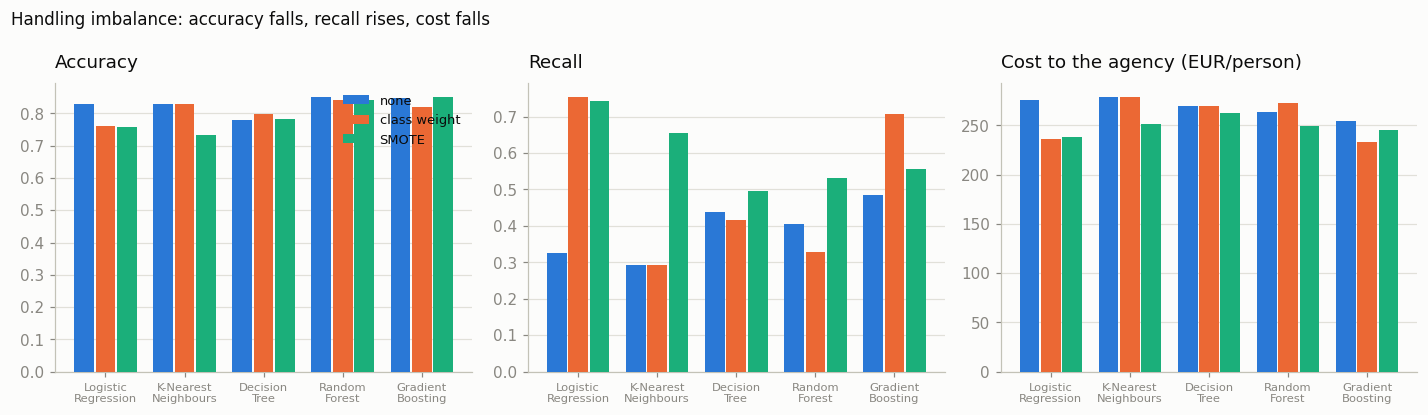

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=False)
strategies = ['none', 'class weight', 'SMOTE']
for ax, metric, nice in zip(axes, ['accuracy', 'recall', 'agency EUR'],
                            ['Accuracy', 'Recall', 'Cost to the agency (EUR/person)']):
    positions = np.arange(len(MODEL_ORDER))
    for i, strategy in enumerate(strategies):
        ax.bar(positions + (i - 1) * 0.27, comparison[(strategy, metric)].values, 0.25,
               color=SERIES[i], label=strategy, zorder=3)
    ax.set_xticks(positions, [m.replace(' ', '\n') for m in MODEL_ORDER], fontsize=7.5)
    ax.set_title(nice, loc='left', pad=10)
    ax.grid(axis='x', visible=False)
axes[0].legend(fontsize=8.5)
fig.suptitle('Handling imbalance: accuracy falls, recall rises, cost falls', x=0.005,
             ha='left', fontsize=11)
plt.tight_layout(); plt.show()

**The findings — and the middle one is the one that gets missed.**

**Accuracy goes down for every model.** Taken at face value that looks like the change made
things worse, and a student reporting accuracy alone would conclude exactly that.

**Recall roughly doubles, and cost to the agency falls for every model.** That is what the
change actually did: it moved each model along the precision/recall trade-off towards catching
people. The agency, which pays €1,600 every time someone is missed, is far better off. Accuracy
fell because accuracy is dominated by the ~80% of people who were never going to have a
high-needs year, and getting those right is worth very little to either stakeholder.

**Class weighting does nothing at all for K-Nearest Neighbours** — the row is unchanged, because
there is no such parameter to set. SMOTE is the option that works for it, and this is the
clearest illustration in the notebook of why more than one technique exists for the same problem.

**Class weighting barely moves the two unconstrained tree models, and slightly *lowers* their
recall.** That is not a fluke. A decision tree or random forest left to grow without limit can
drive its training error to nearly zero whichever way the classes are weighted, so there is very
little for the weights to change. The weighting only starts to bite once the tree is constrained
— which is exactly what Stage 6 does, and why the trees post their largest gains there rather
than here. Two changes that each look modest in isolation are worth a great deal together.

Between the two strategies: class weighting and SMOTE land in broadly the same place for the
models that support both. Class weighting is cheaper, invents no data, and leaves the training
set honest, so it is the better default — a submission reaching for SMOTE should say why.

---
## Stage 6 — hyperparameter tuning

Defaults are a guess made by a library author who has never seen this data. Every model gets a
grid search, scored on F1, with class weighting kept on where it is available.

In [13]:
GRIDS = {
    'Logistic Regression':  {'C': [0.05, 0.5, 5.0]},
    'K-Nearest Neighbours': {'n_neighbors': [5, 25, 75], 'weights': ['uniform', 'distance']},
    'Decision Tree':        {'max_depth': [4, 8, 12, None], 'min_samples_leaf': [5, 20, 50]},
    'Random Forest':        {'max_depth': [8, 12, None], 'min_samples_leaf': [1, 5, 20]},
    'Gradient Boosting':    {'max_leaf_nodes': [15, 31], 'learning_rate': [0.05, 0.1],
                             'min_samples_leaf': [20, 50]},
}

# Each model is tuned on the same data it will be fitted on, so K-NN is tuned against
# the SMOTE-resampled training set.
S_smote_fit, y_smote_fit = SMOTE(random_state=RANDOM_STATE).fit_resample(S_train, y_train)

best_params = {}
for name, estimator in build_models(class_weight='balanced').items():
    fit_X, fit_y = (S_smote_fit, y_smote_fit) if name in SMOTE_MODELS else (S_train, y_train)
    search = GridSearchCV(estimator, GRIDS[name], scoring='f1', cv=5, n_jobs=-1)
    search.fit(fit_X, fit_y)
    best_params[name] = search.best_params_
    print(f'{name:<22} {search.best_params_}')
print()

stage6, tuned_models = evaluate(build_models(class_weight='balanced', tuned=best_params),
                                S_train, y_train, S_val, y_val, stage='6 tuned',
                                smote_for=SMOTE_MODELS)
show(stage6)
print()
show(delta('6 tuned', '5 imbalance handled'), 'change against Stage 5:')

Logistic Regression    {'C': 0.5}


K-Nearest Neighbours   {'n_neighbors': 5, 'weights': 'distance'}


Decision Tree          {'max_depth': 8, 'min_samples_leaf': 20}


Random Forest          {'max_depth': 12, 'min_samples_leaf': 5}


Gradient Boosting      {'learning_rate': 0.1, 'max_leaf_nodes': 15, 'min_samples_leaf': 20}



                      accuracy  balanced_acc  precision  recall     f1  agency EUR  employer EUR
model                                                                                           
Logistic Regression      0.760         0.758      0.438   0.755  0.555     236.390       361.845
K-Nearest Neighbours     0.736         0.705      0.398   0.654  0.495     251.665       374.670
Decision Tree            0.763         0.775      0.445   0.795  0.571     231.300       359.775
Random Forest            0.840         0.767      0.586   0.646  0.615     236.935       328.005
Gradient Boosting        0.811         0.805      0.515   0.795  0.625     224.100       338.175

change against Stage 5:
                      accuracy  recall     f1  agency EUR
model                                                    
Logistic Regression      0.000   0.000  0.000       0.000
K-Nearest Neighbours     0.001   0.000  0.001      -0.150
Decision Tree           -0.035   0.379  0.120     -38.175
Random

**The findings.**

**Tuning is not uniformly valuable, and the table makes that visible.** The tree-based models
gain substantially, and this is where Stage 5's class weighting finally pays off for them: an
unconstrained tree grows until it has memorised the training set, so the weights had nothing to
act on. Constrain depth and leaf size and the weighting starts to matter — recall for the
decision tree and the random forest jumps by more than 0.3. Logistic regression's
regularisation strength moves almost nothing, because the model has very little capacity to
over- or under-use in the first place.

Knowing *which* knobs matter for which model family is the actual skill here. A submission that
tunes everything and reports only the models that improved has hidden the more interesting half
of the result.

---
## Stage 7 — the validation method

Every number so far has come from one 80/20 split with one seed. How much of the difference
between these models is real, and how much is the split?

In [14]:
folds = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'accuracy': 'accuracy', 'recall': 'recall', 'f1': 'f1',
           'balanced_acc': 'balanced_accuracy'}

rows = []
for name, model in build_models(class_weight='balanced', tuned=best_params).items():
    # K-NN is cross-validated on SMOTE-resampled data, matching how it is fitted.
    cv_X, cv_y = (pd.concat([S_train, S_val]), pd.concat([y_train, y_val]))
    if name in SMOTE_MODELS:
        cv_X, cv_y = SMOTE(random_state=RANDOM_STATE).fit_resample(cv_X, cv_y)
    cv = cross_validate(model, cv_X, cv_y, cv=folds, scoring=scoring, n_jobs=-1)
    rows.append({
        'model': name,
        'single split F1': stage6.loc[name, 'f1'],
        'CV F1 mean': cv['test_f1'].mean(),
        'CV F1 sd': cv['test_f1'].std(),
        'CV accuracy': cv['test_accuracy'].mean(),
        'CV balanced acc': cv['test_balanced_acc'].mean(),
        'CV recall': cv['test_recall'].mean(),
    })
cv_results = pd.DataFrame(rows).set_index('model').reindex(MODEL_ORDER)
show(cv_results, 'five-fold cross-validation vs the single split:')

five-fold cross-validation vs the single split:
                      single split F1  CV F1 mean  CV F1 sd  CV accuracy  CV balanced acc  CV recall
model                                                                                               
Logistic Regression             0.555       0.534     0.008        0.746            0.743      0.737
K-Nearest Neighbours            0.495       0.874     0.003        0.859            0.859      0.982
Decision Tree                   0.571       0.545     0.007        0.753            0.750      0.745
Random Forest                   0.615       0.595     0.016        0.827            0.758      0.644
Gradient Boosting               0.625       0.599     0.015        0.796            0.786      0.771


In [15]:
# How often would a single split have picked the wrong winner?
seeds = range(10)
per_seed = {name: [] for name in MODEL_ORDER}
for seed in seeds:
    a, b, c, d = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)
    fold_scaler = StandardScaler().fit(a)
    seed_smote = SMOTE(random_state=seed).fit_resample(fold_scaler.transform(a), c)
    for name, model in build_models(class_weight='balanced', tuned=best_params).items():
        if name in SMOTE_MODELS:
            model.fit(*seed_smote)
        else:
            model.fit(fold_scaler.transform(a), c)
        per_seed[name].append(f1_score(d, model.predict(fold_scaler.transform(b))))

spread = pd.DataFrame(per_seed).agg(['mean', 'std', 'min', 'max']).T.reindex(MODEL_ORDER)
show(spread, 'positive-class F1 across 10 different random splits:')

winners = pd.DataFrame(per_seed).idxmax(axis=1).value_counts()
print()
print('model that would have "won" on a single split, by seed:')
print(winners.to_string())

positive-class F1 across 10 different random splits:
                       mean    std    min    max
Logistic Regression   0.533  0.010  0.513  0.545
K-Nearest Neighbours  0.472  0.011  0.448  0.492
Decision Tree         0.544  0.011  0.531  0.568
Random Forest         0.594  0.024  0.555  0.628
Gradient Boosting     0.596  0.018  0.558  0.624

model that would have "won" on a single split, by seed:
Random Forest        5
Gradient Boosting    5


**The findings.**

**Cross-validation and the single split disagree**, and not by a trivial amount for some models.
The single-split figure is one draw from the distribution in the second table, not a property of
the model.

**Which model "wins" depends on the seed.** Over ten splits the winner changes more than once,
and the models involved are separated by less than their own spread across splits. A student who
ran one split and declared a winner would be reporting noise.

**And this is where accuracy finally behaves.** Cross-validated *balanced* accuracy rises across
the board — it is the metric that rewards getting both classes right rather than the majority
one, so unlike plain accuracy it moves in the same direction as every other improvement. If you
want a single headline number that behaves sensibly on an imbalanced problem, it is balanced
accuracy or F1, not accuracy.

---
## Stage 8 — cost, and who is paying

Every metric so far has treated a miss and a false alarm as equally regrettable. Neither
stakeholder does. All five tuned models, priced under both cost matrices, against the only
reference point that matters: **what it would cost to invite nobody at all.**

In [16]:
nothing_agency = do_nothing_cost(y_val, COST_PUBLIC_HEALTH)
nothing_employer = do_nothing_cost(y_val, COST_EMPLOYER)

costs = stage6[['accuracy', 'precision', 'recall', 'f1', 'agency EUR', 'employer EUR']].copy()
costs['agency saving'] = nothing_agency - costs['agency EUR']
costs['employer saving'] = nothing_employer - costs['employer EUR']

print(f'inviting nobody costs the agency   EUR {nothing_agency:7.2f} per person')
print(f'inviting nobody costs the employer EUR {nothing_employer:7.2f} per person')
print()
show(costs, 'all five models, priced for both customers:')
print()
print(f'cheapest for the agency  : {costs["agency EUR"].idxmin()}')
print(f'cheapest for the employer: {costs["employer EUR"].idxmin()}')
print(f'most accurate            : {costs["accuracy"].idxmax()}')

inviting nobody costs the agency   EUR  316.80 per person
inviting nobody costs the employer EUR  356.40 per person

all five models, priced for both customers:
                      accuracy  precision  recall     f1  agency EUR  employer EUR  agency saving  employer saving
model                                                                                                             
Logistic Regression      0.760      0.438   0.755  0.555     236.390       361.845         80.410           -5.445
K-Nearest Neighbours     0.736      0.398   0.654  0.495     251.665       374.670         65.135          -18.270
Decision Tree            0.763      0.445   0.795  0.571     231.300       359.775         85.500           -3.375
Random Forest            0.840      0.586   0.646  0.615     236.935       328.005         79.865           28.395
Gradient Boosting        0.811      0.515   0.795  0.625     224.100       338.175         92.700           18.225

cheapest for the agency  : Gradie

In [17]:
# Which pairs of models do the two customers rank in OPPOSITE order?
found = 0
for i, one in enumerate(MODEL_ORDER):
    for other in MODEL_ORDER[i + 1:]:
        agency = one if costs.loc[one, 'agency EUR'] < costs.loc[other, 'agency EUR'] else other
        employer = one if costs.loc[one, 'employer EUR'] < costs.loc[other, 'employer EUR'] else other
        if agency != employer:
            found += 1
            print(f'DISAGREEMENT  {one}  vs  {other}')
            print(f'    agency prefers   {agency}')
            print(f'    employer prefers {other if agency == one else one}')
print(f'\n{found} pair(s) of models split the two stakeholders.')

DISAGREEMENT  Logistic Regression  vs  Random Forest
    agency prefers   Logistic Regression
    employer prefers Random Forest
DISAGREEMENT  Decision Tree  vs  Random Forest
    agency prefers   Decision Tree
    employer prefers Random Forest
DISAGREEMENT  Random Forest  vs  Gradient Boosting
    agency prefers   Gradient Boosting
    employer prefers Random Forest

3 pair(s) of models split the two stakeholders.


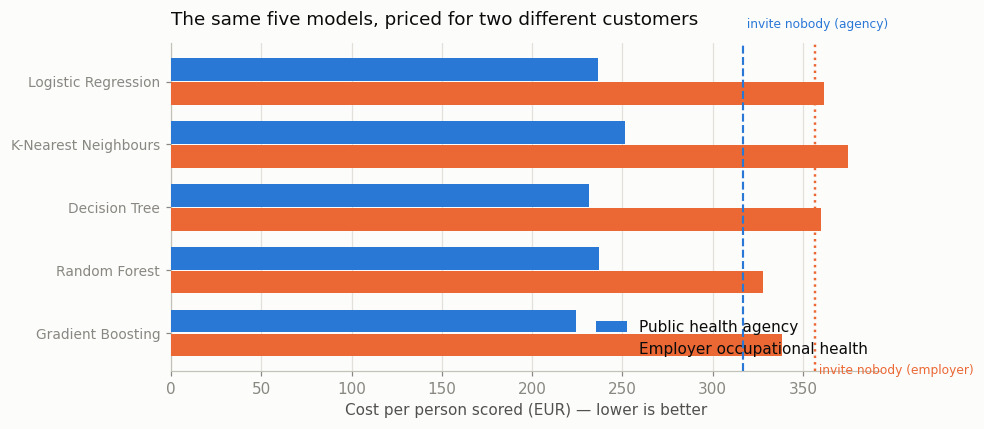

In [18]:
fig, ax = plt.subplots(figsize=(9, 4))
positions = np.arange(len(MODEL_ORDER))
ax.barh(positions - 0.19, costs['agency EUR'], 0.36, color=SERIES[0],
        label='Public health agency', zorder=3)
ax.barh(positions + 0.19, costs['employer EUR'], 0.36, color=SERIES[1],
        label='Employer occupational health', zorder=3)
ax.axvline(nothing_agency, color=SERIES[0], linestyle='--', linewidth=1.4, zorder=4)
ax.axvline(nothing_employer, color=SERIES[1], linestyle=':', linewidth=1.6, zorder=4)
ax.text(nothing_agency, -0.85, ' invite nobody (agency)', fontsize=8, color=SERIES[0])
ax.text(nothing_employer, len(MODEL_ORDER) - 0.35, ' invite nobody (employer)',
        fontsize=8, color=SERIES[1])
ax.set_yticks(positions, MODEL_ORDER, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Cost per person scored (EUR) — lower is better')
ax.set_title('The same five models, priced for two different customers', loc='left', pad=12)
ax.legend(loc='lower right')
ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

**The findings.**

**Every cost is a real cost.** There is no cell in either matrix where someone makes money: a
correctly invited person still costs the programme fee plus whatever burden the programme does
not avert. The dashed lines are the do-nothing reference — invite nobody, pay for every case you
missed. A model is only worth deploying if it lands to the left of its customer's line.

**The programme is worth far more to the agency than to the employer.** The best model saves the
agency roughly four times what the best model saves the employer, per person. The agency pays
€1,600 for every miss and only €150 for a wasted place, so casting a wide net is cheap. The
employer's scarce places cost €450 each against €1,800 of avoidable absence that the programme
only partly averts — so it has to be much more confident before it spends, and gains less when
it is right.

**The two customers rank models in opposite orders**, and the clearest case is the same algorithm
twice — one with `class_weight='balanced'` and one without. One flag moves precision and recall
in opposite directions, and that is enough to flip which customer wants it.

**The most accurate model is not what the agency wants.** Accuracy is dominated by the people who
were never going to need help, and getting those right earns the agency nothing.

A recommendation should be made to each customer in their own terms, with their own number.
"Model X is best" is not an answer to either of them.

---
## Stage 9 — the leakage trap

Every model since Stage 3 has excluded `SelfRatedHealth`. Here is what putting it back does —
to all five models at once.

In [19]:
X_leak, y_leak = encode(dev_clean, keep_self_rated_health=True)
XL_train, XL_val, yL_train, yL_val = train_test_split(
    X_leak, y_leak, test_size=0.2, stratify=y_leak, random_state=RANDOM_STATE)
leak_scaler = StandardScaler().fit(XL_train)
SL_train = pd.DataFrame(leak_scaler.transform(XL_train), columns=XL_train.columns)
SL_val = pd.DataFrame(leak_scaler.transform(XL_val), columns=XL_val.columns)

stage9, _ = evaluate(build_models(class_weight='balanced', tuned=best_params),
                     SL_train, yL_train, SL_val, yL_val, stage='9 with leakage',
                     record=False, smote_for=SMOTE_MODELS)
show(stage9, 'WITH SelfRatedHealth in the feature set:')
print()
show((stage9[['accuracy', 'recall', 'f1', 'agency EUR']]
      - stage6[['accuracy', 'recall', 'f1', 'agency EUR']]).round(3),
     'change against the honest Stage 6 models:')

WITH SelfRatedHealth in the feature set:
                      accuracy  balanced_acc  precision  recall     f1  agency EUR  employer EUR
model                                                                                           
Logistic Regression      0.791         0.787      0.483   0.780  0.597     228.840       347.445
K-Nearest Neighbours     0.760         0.742      0.436   0.712  0.541     241.245       362.385
Decision Tree            0.800         0.800      0.497   0.801  0.613     225.170       343.035
Random Forest            0.852         0.789      0.615   0.684  0.648     230.635       321.480
Gradient Boosting        0.832         0.826      0.552   0.816  0.659     218.555       328.140

change against the honest Stage 6 models:
                      accuracy  recall     f1  agency EUR
model                                                    
Logistic Regression      0.031   0.025  0.042      -7.550
K-Nearest Neighbours     0.025   0.058  0.046     -10.420
Decis

**The finding.** `SelfRatedHealth` delivers a free and consistent improvement to every model. It
is also unusable, for two independent reasons.

**It would not exist at prediction time.** The deployment scenario is scoring people from
routinely held administrative and wearable data. `SelfRatedHealth` comes from the survey, and the
survey is not run on the population either stakeholder wants to screen. A model that depends on
it cannot be deployed at all — the column is simply absent.

**It is a measurement of the thing being predicted.** Self-rated health is well known to predict
later mortality and healthcare use *after* adjusting for every measured risk factor, because
respondents incorporate information no questionnaire captures. That is exactly why it helps here,
and exactly why using it is circular.

Worth stressing for marking: nothing about the modelling flags this. The pipeline runs,
cross-validation agrees, the test score improves. The only defence is reading the column list and
asking, of each feature, *would I have this, for this person, at the moment I need to decide?*

---
## Stage 10 — three different numbers for "how good is it?"

In [20]:
X_full = pd.concat([S_train, S_val])
y_full = pd.concat([y_train, y_val])

test_X, test_y = encode(test_raw)
test_X = pd.DataFrame(scaler.transform(test_X.reindex(columns=X.columns, fill_value=0)),
                      columns=X.columns)

full_smote = SMOTE(random_state=RANDOM_STATE).fit_resample(X_full, y_full)

rows = []
for name, model in build_models(class_weight='balanced', tuned=best_params).items():
    fit_X, fit_y = full_smote if name in SMOTE_MODELS else (X_full, y_full)
    model.fit(fit_X, fit_y)
    resubstitution = accuracy_score(y_full, model.predict(X_full))
    cv = cross_validate(build_models(class_weight='balanced', tuned=best_params)[name],
                        fit_X, fit_y, cv=folds, scoring=['accuracy', 'f1'], n_jobs=-1)
    rows.append({
        'model': name,
        'train (resubstitution)': resubstitution,
        '5-fold CV': cv['test_accuracy'].mean(),
        'held-out test': accuracy_score(test_y, model.predict(test_X)),
        'optimism (train - CV)': resubstitution - cv['test_accuracy'].mean(),
        'shift penalty (CV - test)': cv['test_accuracy'].mean() - accuracy_score(test_y, model.predict(test_X)),
    })
honesty = pd.DataFrame(rows).set_index('model').reindex(MODEL_ORDER)
show(honesty, 'accuracy, measured three different ways:')

accuracy, measured three different ways:
                      train (resubstitution)  5-fold CV  held-out test  optimism (train - CV)  shift penalty (CV - test)
model                                                                                                                   
Logistic Regression                    0.746      0.746          0.673                 -0.000                      0.073
K-Nearest Neighbours                   1.000      0.859          0.688                  0.141                      0.171
Decision Tree                          0.778      0.753          0.727                  0.025                      0.026
Random Forest                          0.914      0.827          0.810                  0.088                      0.017
Gradient Boosting                      0.832      0.796          0.771                  0.036                      0.025


**The findings.**

**Scoring on the training data is meaningless**, and the size of the gap varies enormously by
model — the tree-based models memorise far more of the training set than logistic regression can.
This number should never appear in a report as an estimate of performance.

**Cross-validation is honest about the development set but still optimistic about the test set.**
The remaining gap is not overfitting; cross-validation already controlled for that. It is a
property of the test set, and Stage 11 takes it apart.

---
## Stage 11 — is the test set representative?

The deepest layer, and where the highest marks are.

In [21]:
comparison = pd.DataFrame({
    'development': [len(dev_raw), dev_raw[TARGET].mean(),
                    dev_raw['Age'].where(dev_raw['Age'] <= 100).mean(),
                    (dev_raw['Country'] == 'UK').mean(),
                    (dev_raw['Smoking Status'] == 'Vaper').mean(),
                    dev_raw.duplicated().mean(),
                    (dev_raw['Age'] > 100).mean(), (dev_raw['BMI'] > 60).mean(),
                    dev_raw.isna().any(axis=1).mean()],
    'test': [len(test_raw), test_raw[TARGET].mean(),
             test_raw['Age'].where(test_raw['Age'] <= 100).mean(),
             (test_raw['Country'] == 'UK').mean(),
             (test_raw['Smoking Status'] == 'Vaper').mean(),
             test_raw.duplicated().mean(),
             (test_raw['Age'] > 100).mean(), (test_raw['BMI'] > 60).mean(),
             test_raw.isna().any(axis=1).mean()],
}, index=['rows', 'positive rate', 'mean age (valid)', 'share UK', 'share vaping',
          'duplicate rows', 'age anomalies', 'BMI anomalies', 'rows with missing data'])
print(comparison.round(4).to_string())
print(f"\nduplicates in the test set that are UK rows: "
      f"{(test_raw[test_raw.duplicated()]['Country'] == 'UK').mean():.0%}")

                        development       test
rows                     10040.0000  3060.0000
positive rate                0.1977     0.2562
mean age (valid)            40.6888    46.1588
share UK                     0.2498     0.4673
share vaping                 0.0267     0.0971
duplicate rows               0.0040     0.0196
age anomalies                0.0071     0.0330
BMI anomalies                0.0056     0.0167
rows with missing data       0.2617     0.0000

duplicates in the test set that are UK rows: 83%


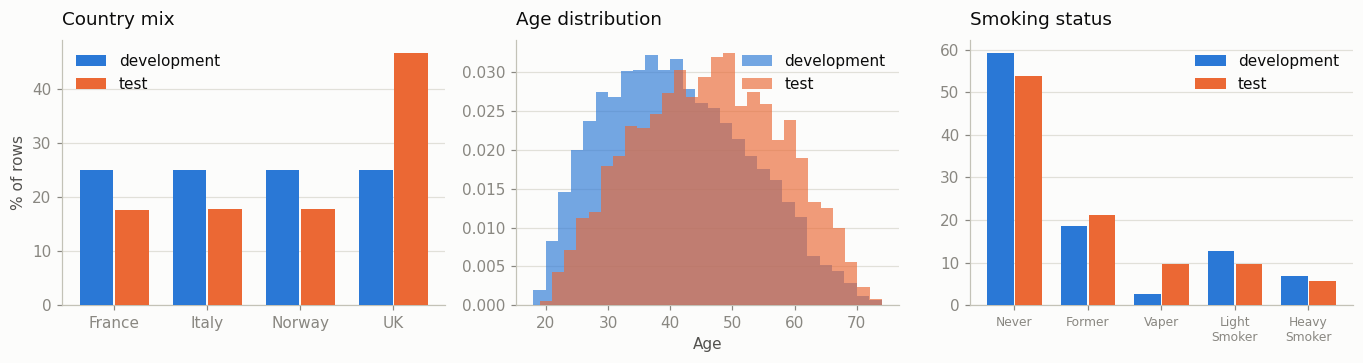

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))
mix = pd.DataFrame({'development': dev_raw['Country'].value_counts(normalize=True),
                    'test': test_raw['Country'].value_counts(normalize=True)}).sort_index()
positions = np.arange(len(mix))
axes[0].bar(positions - 0.19, mix['development'] * 100, 0.36, color=SERIES[0],
            label='development', zorder=3)
axes[0].bar(positions + 0.19, mix['test'] * 100, 0.36, color=SERIES[1], label='test', zorder=3)
axes[0].set_xticks(positions, mix.index); axes[0].set_ylabel('% of rows')
axes[0].set_title('Country mix', loc='left', pad=10); axes[0].legend()
axes[0].grid(axis='x', visible=False)

axes[1].hist(dev_raw['Age'].where(dev_raw['Age'] <= 100).dropna(), bins=28, density=True,
             color=SERIES[0], alpha=0.65, label='development', zorder=3)
axes[1].hist(test_raw['Age'].where(test_raw['Age'] <= 100).dropna(), bins=28, density=True,
             color=SERIES[1], alpha=0.65, label='test', zorder=3)
axes[1].set_xlabel('Age'); axes[1].set_title('Age distribution', loc='left', pad=10)
axes[1].legend(); axes[1].grid(axis='x', visible=False)

smoke = pd.DataFrame({'development': dev_raw['Smoking Status'].value_counts(normalize=True),
                      'test': test_raw['Smoking Status'].value_counts(normalize=True)}
                     ).reindex(ORDINAL_SCALES['Smoking Status'])
positions = np.arange(len(smoke))
axes[2].bar(positions - 0.19, smoke['development'] * 100, 0.36, color=SERIES[0],
            label='development', zorder=3)
axes[2].bar(positions + 0.19, smoke['test'] * 100, 0.36, color=SERIES[1], label='test', zorder=3)
axes[2].set_xticks(positions, [s.replace(' ', '\n') for s in smoke.index], fontsize=8)
axes[2].set_title('Smoking status', loc='left', pad=10); axes[2].legend()
axes[2].grid(axis='x', visible=False)
plt.tight_layout(); plt.show()

### Is the higher positive rate a change in risk, or a change in who was recruited?

In [23]:
band = lambda frame: pd.cut(frame['Age'].where(frame['Age'] <= 100), [0, 30, 45, 60, 100])
dev_band, test_band = band(dev_raw), band(test_raw)

def reweighted(dev_keys, test_keys):
    rates = dev_raw.groupby(dev_keys, observed=True)[TARGET].mean()
    mix = test_raw.groupby(test_keys, observed=True).size() / len(test_raw)
    shared = rates.index.intersection(mix.index)
    return float((rates[shared] * mix[shared]).sum())

print(f"development positive rate              {dev_raw[TARGET].mean():.3f}")
print(f"test positive rate                     {test_raw[TARGET].mean():.3f}")
print()
print(f"reweighted by country only             {reweighted(dev_raw['Country'], test_raw['Country']):.3f}")
print(f"reweighted by age band only            {reweighted(dev_band, test_band):.3f}")
print(f"reweighted by country + age + smoking  "
      f"{reweighted([dev_raw['Country'], dev_band, dev_raw['Smoking Status']], [test_raw['Country'], test_band, test_raw['Smoking Status']]):.3f}")

development positive rate              0.198
test positive rate                     0.256

reweighted by country only             0.211
reweighted by age band only            0.210
reweighted by country + age + smoking  0.232


In [24]:
# The decisive test, without needing probabilities: if the RELATIONSHIP had changed, the
# model would get worse at identifying cases WITHIN a subgroup. If only the mix changed,
# per-subgroup performance holds and only the overall numbers move.
best_name = costs['agency EUR'].idxmin()
best_model = build_models(class_weight='balanced', tuned=best_params)[best_name]
if best_name in SMOTE_MODELS:
    best_model.fit(*SMOTE(random_state=RANDOM_STATE).fit_resample(S_train, y_train))
else:
    best_model.fit(S_train, y_train)
val_rows = dev_clean.loc[X_val.index]

val_predictions = best_model.predict(S_val)
test_predictions = best_model.predict(test_X)
print(f'using the agency\'s preferred model: {best_name}')
print(f'  validation  recall={recall_score(y_val, val_predictions):.3f}  '
      f'precision={precision_score(y_val, val_predictions):.3f}  '
      f'accuracy={accuracy_score(y_val, val_predictions):.3f}')
print(f'  test        recall={recall_score(test_y, test_predictions):.3f}  '
      f'precision={precision_score(test_y, test_predictions):.3f}  '
      f'accuracy={accuracy_score(test_y, test_predictions):.3f}')

per_country = []
for country in sorted(test_raw['Country'].unique()):
    in_validation = (val_rows['Country'].values == country)
    in_test = (test_raw['Country'].values == country)
    per_country.append({
        'country': country,
        'validation precision': precision_score(y_val[in_validation],
                                                val_predictions[in_validation], zero_division=0),
        'test precision': precision_score(test_y[in_test], test_predictions[in_test],
                                          zero_division=0),
        'validation recall': recall_score(y_val[in_validation], val_predictions[in_validation]),
        'test recall': recall_score(test_y[in_test], test_predictions[in_test]),
    })
per_country = pd.DataFrame(per_country).set_index('country')
print()
show(per_country, 'within each country:')
gap = (per_country['validation precision'] - per_country['test precision']).abs().mean()
print(f'\nmean absolute precision gap across countries: {gap:.3f}')

using the agency's preferred model: Gradient Boosting
  validation  recall=0.795  precision=0.515  accuracy=0.811
  test        recall=0.837  precision=0.543  accuracy=0.778

within each country:
         validation precision  test precision  validation recall  test recall
country                                                                      
France                  0.527           0.565              0.870        0.927
Italy                   0.464           0.483              0.797        0.798
Norway                  0.617           0.566              0.860        0.825
UK                      0.464           0.546              0.675        0.817

mean absolute precision gap across countries: 0.047


**The finding — and it is the important one.** The rise is **compositional**, not a change in
underlying risk.

Reweighting the development set's own within-group rates to the test set's mix of country, age
band and smoking status recovers most of the gap. Coarse stratification on three variables does
not close it completely, and should not be expected to.

The decisive evidence is what happens **inside** each subgroup. Precision barely moves, so a
positive prediction on the test set is about as trustworthy as one made on the validation split,
and recall holds or improves. A model whose learned relationship had gone stale would get
**worse** at identifying cases within a country, not better.

Put it together: accuracy falls while precision and recall hold or improve. That is the signature
of a population containing more positive cases, not of a model that has stopped working.

So what the model learned is intact; what changed is **who was recruited**. This is covariate
shift, not concept drift, and the distinction has consequences: the model does not need
retraining, but the **costs each stakeholder should expect do need recalculating**, because they
were estimated against a population with a different mix.

A submission reporting "the test set has a higher positive rate, so the data has drifted and the
model is stale" has stopped one step too early.

---
## Stage 12 — the whole journey, and the benchmark

Every result recorded at every stage, for every model.

In [25]:
journey = pd.DataFrame(RESULTS)
print('NOTE: stages 1 and 2 still include SelfRatedHealth in the feature set, exactly as')
print('the starter notebook does. It is dropped from Stage 3 onwards, which is why several')
print('models look WORSE at Stage 3 -- the leak was flattering them. See Stage 9.')
print()
for metric in ['accuracy', 'recall', 'f1', 'balanced_acc', 'agency EUR']:
    print(f'--- {metric} ---')
    table = journey.pivot_table(index='stage', columns='model', values=metric, sort=False)
    print(table.reindex(columns=[m for m in MODEL_ORDER if m in table.columns]).round(3).to_string())
    print()

NOTE: stages 1 and 2 still include SelfRatedHealth in the feature set, exactly as
the starter notebook does. It is dropped from Stage 3 onwards, which is why several
models look WORSE at Stage 3 -- the leak was flattering them. See Stage 9.

--- accuracy ---
model                Logistic Regression  K-Nearest Neighbours  Decision Tree  Random Forest  Gradient Boosting
stage                                                                                                          
1 starter                          0.855                 0.766            NaN            NaN                NaN
2 more models                      0.855                 0.766          0.816          0.873              0.873
3 data quality                     0.802                 0.776          0.780          0.850              0.850
4 scaling                          0.830                 0.828          0.781          0.850              0.850
5 imbalance handled                0.760                 0.734       

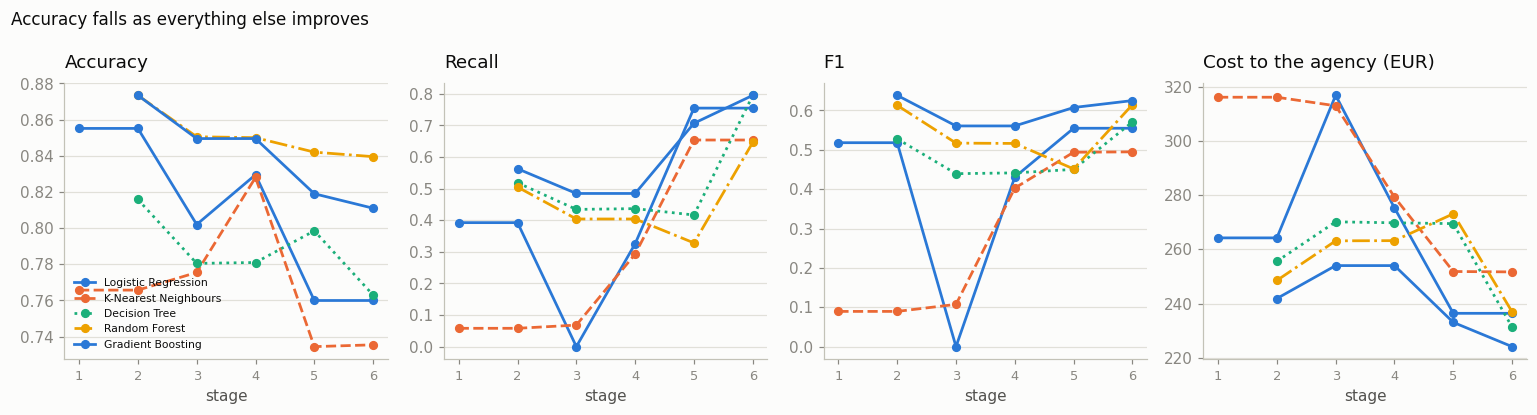

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
stage_order = [s for s in journey['stage'].unique()]
for ax, metric, nice in zip(axes,
                            ['accuracy', 'recall', 'f1', 'agency EUR'],
                            ['Accuracy', 'Recall', 'F1', 'Cost to the agency (EUR)']):
    table = journey.pivot_table(index='stage', columns='model', values=metric,
                                sort=False).reindex(stage_order)
    for i, model in enumerate([m for m in MODEL_ORDER if m in table.columns]):
        ax.plot(range(len(table)), table[model], marker='o', markersize=5, linewidth=1.8,
                color=SERIES[i % len(SERIES)],
                linestyle=['-', '--', ':', '-.', '-'][i % 5], label=model, zorder=3)
    ax.set_xticks(range(len(table)), [s.split(' ', 1)[0] for s in table.index], fontsize=8.5)
    ax.set_xlabel('stage')
    ax.set_title(nice, loc='left', pad=10)
    ax.grid(axis='x', visible=False)
axes[0].legend(fontsize=7, loc='lower left')
fig.suptitle('Accuracy falls as everything else improves', x=0.005, ha='left', fontsize=11)
plt.tight_layout(); plt.show()

### Accuracy going down is the point, not a problem

The trajectory charts make the pattern unmissable: as the pipeline improves, **recall, F1,
balanced accuracy and cost all get better together, and plain accuracy gets worse.**

That is what *must* happen on an imbalanced problem. About 80% of these people were never going
to have a year of high health needs, and a model can score 80% accuracy by saying so about
everybody — which is precisely the model that is worth nothing to either customer. Every step
that makes the model more useful moves it away from that behaviour, and accuracy records the move
as a loss.

**Balanced accuracy is the metric that behaves the way accuracy is supposed to.** It averages
performance on the two classes rather than letting the majority dominate, and it climbs steadily
across the stages. If a single headline number is wanted for an imbalanced problem, it should be
balanced accuracy or F1 — never accuracy.

This is also why the cost matrices exist. They convert "recall up, accuracy down" from an
argument about which metric to prefer into a number in euros that a stakeholder can act on.

In [27]:
# The benchmark: refit on the FULL development set, scored once on the held-out test set.
print('Held-out test set — the benchmark everyone is compared on\n')
rows = []
for name, model in build_models(class_weight='balanced', tuned=best_params).items():
    fit_X, fit_y = full_smote if name in SMOTE_MODELS else (X_full, y_full)
    model.fit(fit_X, fit_y)
    rows.append({'model': name, **score(test_y, model.predict(test_X))})

# The starter pipeline, exactly as handed out, for comparison.
starter_test_X, starter_test_y = encode(test_raw, keep_self_rated_health=True)
starter_test_X = starter_test_X.reindex(columns=X_naive.columns, fill_value=0)
starter_model = LogisticRegression().fit(X_naive, y_naive)
rows.insert(0, {'model': 'Starter LR (as handed out)',
                **score(starter_test_y, starter_model.predict(starter_test_X))})

benchmark = pd.DataFrame(rows).set_index('model')
show(benchmark)
print()
print(f'inviting nobody would cost the agency   EUR {do_nothing_cost(test_y, COST_PUBLIC_HEALTH):.2f}')
print(f'inviting nobody would cost the employer EUR {do_nothing_cost(test_y, COST_EMPLOYER):.2f}')
print()
print(f'best for the agency  : {benchmark["agency EUR"].idxmin()}')
print(f'best for the employer: {benchmark["employer EUR"].idxmin()}')

Held-out test set — the benchmark everyone is compared on



                            accuracy  balanced_acc  precision  recall     f1  agency EUR  employer EUR
model                                                                                                 
Starter LR (as handed out)     0.762         0.606      0.571   0.287  0.382     364.542       446.324
Logistic Regression            0.673         0.710      0.426   0.787  0.552     303.575       474.794
K-Nearest Neighbours           0.688         0.698      0.434   0.719  0.541     311.464       469.882
Decision Tree                  0.727         0.764      0.481   0.841  0.612     287.526       449.294
Random Forest                  0.810         0.781      0.608   0.723  0.661     292.562       414.794
Gradient Boosting              0.771         0.794      0.534   0.841  0.653     280.908       429.441

inviting nobody would cost the agency   EUR 409.93
inviting nobody would cost the employer EUR 461.18

best for the agency  : Gradient Boosting
best for the employer: Random F

**Benchmark for the cohort.** The figures above are the numbers to beat. Beating them on F1 is
one contest; beating them on cost, for a named stakeholder, is the one that actually matters —
and the two can be won by different models, which is the whole point of Stage 8.

Note what did *not* help along the way: adding more model families at Stage 2, scaling for
anything other than K-Nearest Neighbours, and tuning logistic regression. Reporting the changes
that made no difference is part of the work, not an admission of failure.